In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
datasets = {
    "Orders": orders,
    "Customers": customers,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

In [ ]:
for name, df in datasets.items():
    print(f"\n===== {name} =====")

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        result = pd.DataFrame({
            "Missing Values": missing,
            "Percentage": (missing / len(df) * 100).round(2)
        })
        print(result)
    else:
        print("No missing values")

In [ ]:
for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print(df.dtypes)

In [ ]:
# Convert date columns to datetime

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_approved_at'] = pd.to_datetime(
    orders['order_approved_at']
)

orders['order_delivered_carrier_date'] = pd.to_datetime(
    orders['order_delivered_carrier_date']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date']
)

reviews['review_creation_date'] = pd.to_datetime(
    reviews['review_creation_date']
)

reviews['review_answer_timestamp'] = pd.to_datetime(
    reviews['review_answer_timestamp']
)

print("Date columns converted successfully ✅")

In [ ]:
# Check missing values after converting date columns

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    print(f"\n===== {name} =====")

    if len(missing) > 0:
        print(missing)
    else:
        print("No missing values ✅")

In [ ]:
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('')

print("Reviews comments cleaned ✅")

In [ ]:
print("===== Relationship Validation =====")

# Orders ↔️ Customers
print("Orders with missing customer:",
      (~orders['customer_id'].isin(customers['customer_id'])).sum())

# Order Items ↔️ Orders
print("Order items with missing order:",
      (~order_items['order_id'].isin(orders['order_id'])).sum())

# Order Items ↔️ Products
print("Order items with missing product:",
      (~order_items['product_id'].isin(products['product_id'])).sum())

# Order Items ↔️ Sellers
print("Order items with missing seller:",
      (~order_items['seller_id'].isin(sellers['seller_id'])).sum())

# Payments ↔️ Orders
print("Payments with missing order:",
      (~payments['order_id'].isin(orders['order_id'])).sum())

# Reviews ↔️ Orders
print("Reviews with missing order:",
      (~reviews['order_id'].isin(orders['order_id'])).sum())

In [ ]:
# Build the main analytical dataset

main_data = orders.merge(
    order_items,
    on='order_id',
    how='left'
)

main_data = main_data.merge(
    products,
    on='product_id',
    how='left'
)

main_data = main_data.merge(
    sellers,
    on='seller_id',
    how='left'
)

main_data = main_data.merge(
    customers,
    on='customer_id',
    how='left'
)

print("Main dataset created successfully ✅")
print("Shape:", main_data.shape)

In [ ]:
print("Rows:", main_data.shape[0])
print("Columns:", main_data.shape[1])

print("\nColumns in main_data:")
print(main_data.columns.tolist())

In [ ]:
print(main_data.columns.tolist())

In [ ]:
main_data.describe()

In [ ]:
total_sales = main_data['price'].sum()

print("Total Sales:", round(total_sales, 2))

In [ ]:
average_price = main_data['price'].mean()

print("Average Item Price:", round(average_price, 2))

In [ ]:
print("Unique Orders:", main_data['order_id'].nunique())
print("Unique Customers:", main_data['customer_unique_id'].nunique())
print("Unique Products:", main_data['product_id'].nunique())
print("Unique Sellers:", main_data['seller_id'].nunique())

In [ ]:
total_freight = main_data['freight_value'].sum()

print("Total Freight:", round(total_freight, 2))

In [ ]:
average_freight = main_data['freight_value'].mean()

print("Average Freight:", round(average_freight, 2))

In [ ]:
total_sales = main_data['price'].sum()
average_price = main_data['price'].mean()
total_freight = main_data['freight_value'].sum()
average_freight = main_data['freight_value'].mean()

print("Total Sales:", round(total_sales, 2))
print("Average Item Price:", round(average_price, 2))
print("Total Freight:", round(total_freight, 2))
print("Average Freight:", round(average_freight, 2))

In [ ]:
print("Unique Orders:", main_data['order_id'].nunique())
print("Unique Customers:", main_data['customer_unique_id'].nunique())
print("Unique Products:", main_data['product_id'].nunique())
print("Unique Sellers:", main_data['seller_id'].nunique())

In [ ]:
total_revenue = main_data['price'].sum() + main_data['freight_value'].sum()

print("Total Revenue including Freight:", round(total_revenue, 2))

In [ ]:
print("Highest Item Price:", main_data['price'].max())
print("Lowest Item Price:", main_data['price'].min())

In [ ]:
top_products = (
    main_data.groupby('product_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

In [ ]:
top_categories = (
    main_data.groupby('product_category_name')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_categories)

In [ ]:
category_sales = (
    main_data.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(category_sales)

In [ ]:
payment_counts = payments['payment_type'].value_counts()

print(payment_counts)

In [ ]:
average_review = reviews['review_score'].mean()

print("Average Review Score:", round(average_review, 2))

In [ ]:
review_distribution = reviews['review_score'].value_counts().sort_index()

print(review_distribution)

In [ ]:
order_status = orders['order_status'].value_counts()

print(order_status)

In [ ]:
yearly_sales = (
    main_data.groupby(main_data['order_purchase_timestamp'].dt.year)['price']
    .sum()
)

print(yearly_sales)

In [ ]:
yearly_orders = (
    orders.groupby(orders['order_purchase_timestamp'].dt.year)['order_id']
    .nunique()
)

print(yearly_orders)

In [ ]:
state_sales = (
    main_data.groupby('customer_state')['price']
    .sum()
    .sort_values(ascending=False)
)

print(state_sales.head(10))

In [ ]:
top_sellers = (
    main_data.groupby('seller_id')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_sellers)

In [ ]:
order_values = main_data.groupby('order_id')['price'].sum()

print("Average Order Value:", round(order_values.mean(), 2))

In [ ]:
items_per_order = main_data.groupby('order_id').size()

print("Average Items per Order:", round(items_per_order.mean(), 2))

In [ ]:
analysis_results = {
    "Total Sales": main_data['price'].sum(),
    "Average Item Price": main_data['price'].mean(),
    "Total Freight": main_data['freight_value'].sum(),
    "Average Freight": main_data['freight_value'].mean(),
    "Unique Orders": main_data['order_id'].nunique(),
    "Unique Customers": main_data['customer_unique_id'].nunique(),
    "Unique Products": main_data['product_id'].nunique(),
    "Unique Sellers": main_data['seller_id'].nunique()
}

analysis_results

In [ ]:
yearly_sales = main_data.groupby(
    main_data['order_purchase_timestamp'].dt.year
)['price'].sum()

yearly_sales.plot(kind='bar', figsize=(8,5))

plt.title('Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# =========================================
# IMPORTS
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns


# =========================================
# 1. SALES BY YEAR
# =========================================

yearly_sales = (
    main_data.groupby(main_data['order_purchase_timestamp'].dt.year)['price']
    .sum()
)

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='bar')

plt.title('Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()


# =========================================
# 2. ORDERS BY YEAR
# =========================================

yearly_orders = (
    orders.groupby(orders['order_purchase_timestamp'].dt.year)['order_id']
    .nunique()
)

plt.figure(figsize=(8,5))
yearly_orders.plot(kind='bar')

plt.title('Number of Orders by Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()


# =========================================
# 3. TOP 10 PRODUCT CATEGORIES BY SALES
# =========================================

category_sales = (
    main_data.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
category_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Sales')
plt.xlabel('Sales')
plt.ylabel('Category')
plt.show()


# =========================================
# 4. TOP 10 PRODUCT CATEGORIES BY ITEMS SOLD
# =========================================

top_categories = (
    main_data.groupby('product_category_name')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_categories.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Items Sold')
plt.xlabel('Number of Items')
plt.ylabel('Category')
plt.show()


# =========================================
# 5. PAYMENT METHODS
# =========================================

payment_counts = payments['payment_type'].value_counts()

plt.figure(figsize=(8,5))
payment_counts.plot(kind='bar')

plt.title('Payment Methods')
plt.xlabel('Payment Type')
plt.ylabel('Number of Payments')
plt.xticks(rotation=45)
plt.show()


# =========================================
# 6. REVIEW SCORE DISTRIBUTION
# =========================================

review_distribution = (
    reviews['review_score']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))
review_distribution.plot(kind='bar')

plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()


# =========================================
# 7. ORDER STATUS
# =========================================

order_status = orders['order_status'].value_counts()

plt.figure(figsize=(10,5))
order_status.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()


# =========================================
# 8. TOP 10 STATES BY SALES
# =========================================

state_sales = (
    main_data.groupby('customer_state')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
state_sales.sort_values().plot(kind='barh')

plt.title('Top 10 States by Sales')
plt.xlabel('Sales')
plt.ylabel('State')
plt.show()


# =========================================
# 9. PRICE DISTRIBUTION
# =========================================

plt.figure(figsize=(10,5))
main_data['price'].plot(kind='hist', bins=50)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


# =========================================
# 10. FREIGHT VALUE DISTRIBUTION
# =========================================

plt.figure(figsize=(10,5))
main_data['freight_value'].plot(kind='hist', bins=50)

plt.title('Freight Value Distribution')
plt.xlabel('Freight Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt

# إنشاء فولدر لحفظ الرسومات
output_dir = "/content/drive/MyDrive/Olist_Project/Visualizations"
os.makedirs(output_dir, exist_ok=True)

# 1. Sales by Year
plt.figure(figsize=(8,5))
yearly_sales.plot(kind='bar')
plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "01_sales_by_year.png"), dpi=300)
plt.show()
plt.close()


# 2. Number of Orders by Year
plt.figure(figsize=(8,5))
yearly_orders.plot(kind='bar')
plt.title("Number of Orders by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "02_orders_by_year.png"), dpi=300)
plt.show()
plt.close()


# 3. Top 10 Product Categories by Sales
plt.figure(figsize=(10,6))
category_sales.sort_values().plot(kind='barh')
plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "03_top_categories_by_sales.png"), dpi=300)
plt.show()
plt.close()


# 4. Top 10 Product Categories by Items Sold
category_items = (
    main_data.groupby('product_category_name')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
category_items.sort_values().plot(kind='barh')
plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Items Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "04_top_categories_by_items.png"), dpi=300)
plt.show()
plt.close()


# 5. Payment Methods
plt.figure(figsize=(8,5))
payment_counts.plot(kind='bar')
plt.title("Payment Methods")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "05_payment_methods.png"), dpi=300)
plt.show()
plt.close()


# 6. Review Score Distribution
plt.figure(figsize=(8,5))
review_distribution.plot(kind='bar')
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "06_review_score_distribution.png"), dpi=300)
plt.show()
plt.close()


# 7. Order Status Distribution
plt.figure(figsize=(9,5))
order_status.plot(kind='bar')
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "07_order_status.png"), dpi=300)
plt.show()
plt.close()


# 8. Sales by Customer State
plt.figure(figsize=(10,6))
state_sales.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "08_top_states_by_sales.png"), dpi=300)
plt.show()
plt.close()


# 9. Top 10 Sellers
plt.figure(figsize=(10,6))
top_sellers.sort_values().plot(kind='barh')
plt.title("Top 10 Sellers by Sales")
plt.xlabel("Sales")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "09_top_sellers_by_sales.png"), dpi=300)
plt.show()
plt.close()


# 10. Freight Value Distribution
plt.figure(figsize=(8,5))
main_data['freight_value'].plot(kind='hist', bins=30)
plt.title("Freight Value Distribution")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "10_freight_value_distribution.png"), dpi=300)
plt.show()
plt.close()


print("✅ All 10 visualizations saved successfully!")
print("📁 Folder:", output_dir)

In [ ]:
delivery_data = main_data.dropna(
    subset=['order_purchase_timestamp', 'order_delivered_customer_date']
).copy()

delivery_data['delivery_days'] = (
    delivery_data['order_delivered_customer_date']
    - delivery_data['order_purchase_timestamp']
).dt.total_seconds() / (60 * 60 * 24)

print("Average Delivery Time:", round(delivery_data['delivery_days'].mean(), 2), "days")
print("Minimum Delivery Time:", round(delivery_data['delivery_days'].min(), 2), "days")
print("Maximum Delivery Time:", round(delivery_data['delivery_days'].max(), 2), "days")

In [ ]:
delivery_data['delivery_delay_days'] = (
    delivery_data['order_delivered_customer_date']
    - delivery_data['order_estimated_delivery_date']
).dt.total_seconds() / (60 * 60 * 24)

early_orders = (delivery_data['delivery_delay_days'] <= 0).sum()
late_orders = (delivery_data['delivery_delay_days'] > 0).sum()

print("Orders Delivered On Time:", early_orders)
print("Orders Delivered Late:", late_orders)

In [ ]:
print(
    "Average Delivery Difference:",
    round(delivery_data['delivery_delay_days'].mean(), 2),
    "days"
)

In [ ]:
monthly_sales = (
    main_data.groupby(
        main_data['order_purchase_timestamp'].dt.to_period('M')
    )['price']
    .sum()
)

print(monthly_sales)

In [ ]:
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "11_monthly_sales.png"),
    dpi=300
)
plt.show()
plt.close()

In [ ]:
monthly_orders = (
    orders.groupby(
        orders['order_purchase_timestamp'].dt.to_period('M')
    )['order_id']
    .nunique()
)

print(monthly_orders)

In [ ]:
plt.figure(figsize=(12,5))
monthly_orders.plot(kind='line', marker='o')
plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "12_monthly_orders.png"),
    dpi=300
)
plt.show()
plt.close()

In [ ]:
order_status_percentage = (
    orders['order_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(order_status_percentage)

In [ ]:
[49]
0s
order_status_percentage = (
    orders['order_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(order_status_percentage)
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

In [ ]:
cancelled_orders = (orders['order_status'] == 'canceled').sum()
unavailable_orders = (orders['order_status'] == 'unavailable').sum()
total_orders = orders['order_id'].nunique()

print("Cancelled Orders:", cancelled_orders)
print("Unavailable Orders:", unavailable_orders)

print(
    "Cancellation Rate:",
    round(cancelled_orders / total_orders * 100, 2),
    "%"
)

print(
    "Unavailable Rate:",
    round(unavailable_orders / total_orders * 100, 2),
    "%"
)

In [ ]:
order_status_value = (
    main_data.groupby('order_status')['price']
    .sum()
    .sort_values(ascending=False)
)

print(order_status_value)

In [ ]:
city_sales = (
    main_data.groupby('customer_city')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(city_sales)

In [ ]:
plt.figure(figsize=(10,6))
city_sales.sort_values().plot(kind='barh')
plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "13_top_cities_by_sales.png"),
    dpi=300
)
plt.show()
plt.close()

In [ ]:
average_category_price = (
    main_data.groupby('product_category_name')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(average_category_price)

In [ ]:
plt.figure(figsize=(10,6))
average_category_price.sort_values().plot(kind='barh')
plt.title("Top 10 Categories by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "14_top_categories_average_price.png"),
    dpi=300
)
plt.show()
plt.close()

In [ ]:
price_freight_correlation = main_data[
    ['price', 'freight_value']
].corr()

print(price_freight_correlation)

In [ ]:
analysis_summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Average Item Price',
        'Total Freight',
        'Average Freight',
        'Unique Orders',
        'Unique Customers',
        'Unique Products',
        'Unique Sellers',
        'Average Order Value',
        'Average Items per Order',
        'Average Delivery Time'
    ],
    'Value': [
        main_data['price'].sum(),
        main_data['price'].mean(),
        main_data['freight_value'].sum(),
        main_data['freight_value'].mean(),
        main_data['order_id'].nunique(),
        main_data['customer_unique_id'].nunique(),
        main_data['product_id'].nunique(),
        main_data['seller_id'].nunique(),
        order_values.mean(),
        items_per_order.mean(),
        delivery_data['delivery_days'].mean()
    ]
})

analysis_summary['Value'] = analysis_summary['Value'].round(2)

analysis_summary.to_csv(
    os.path.join(output_dir, "analysis_summary.csv"),
    index=False
)

print("✅ Analysis summary saved successfully!")

In [ ]:
yearly_sales.to_csv(
    os.path.join(output_dir, "yearly_sales.csv")
)

yearly_orders.to_csv(
    os.path.join(output_dir, "yearly_orders.csv")
)

category_sales.to_csv(
    os.path.join(output_dir, "category_sales.csv")
)

state_sales.to_csv(
    os.path.join(output_dir, "state_sales.csv")
)

top_sellers.to_csv(
    os.path.join(output_dir, "top_sellers.csv")
)

monthly_sales.to_csv(
    os.path.join(output_dir, "monthly_sales.csv")
)

monthly_orders.to_csv(
    os.path.join(output_dir, "monthly_orders.csv")
)

print("✅ All analysis tables saved successfully!")

In [ ]:
city_sales = (
    main_data.groupby('customer_city')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(city_sales)

In [ ]:

city_sales.sort_values().plot(kind='barh')

plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "13_top_cities_by_sales.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
category_avg_price = (
    main_data.groupby('product_category_name')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(category_avg_price)

In [ ]:
plt.figure(figsize=(10, 6))

category_avg_price.sort_values().plot(kind='barh')

plt.title("Top 10 Categories by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "14_top_categories_by_avg_price.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
price_review = main_data.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

print(price_review[['price', 'review_score']].head())

In [ ]:
price_review_corr = price_review[['price', 'review_score']].corr()

print(price_review_corr)

In [ ]:
payment_counts = payments['payment_type'].value_counts()

print(payment_counts)

In [ ]:
payment_analysis = (
    payments.groupby('payment_type')['payment_value']
    .agg(['count', 'mean', 'sum'])
    .sort_values('sum', ascending=False)
)

print(payment_analysis)

In [ ]:
customer_spending = (
    main_data.groupby('customer_unique_id')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(customer_spending)

In [ ]:
customer_total_spending = (
    main_data.groupby('customer_unique_id')['price']
    .sum()
)

print(
    "Average Customer Spending:",
    round(customer_total_spending.mean(), 2)
)

In [ ]:
customer_orders = (
    main_data.groupby('customer_unique_id')['order_id']
    .nunique()
)

repeat_customers = (customer_orders > 1).sum()
total_customers = customer_orders.count()

repeat_rate = (repeat_customers / total_customers) * 100

print("Repeat Customers:", repeat_customers)
print("Total Customers:", total_customers)
print("Repeat Purchase Rate:", round(repeat_rate, 2), "%")v

In [ ]:
top_customers_by_orders = (
    main_data.groupby('customer_unique_id')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers_by_orders)

In [ ]:
items_per_order = (
    main_data.groupby('order_id')
    .size()
)

print("Average Items per Order:", round(items_per_order.mean(), 2))
print("Maximum Items in One Order:", items_per_order.max())

In [ ]:
order_revenue = (
    main_data.groupby('order_id')
    .agg({
        'price': 'sum',
        'freight_value': 'sum'
    })
)

order_revenue['total_revenue'] = (
    order_revenue['price'] +
    order_revenue['freight_value']
)

print(
    "Average Order Revenue:",
    round(order_revenue['total_revenue'].mean(), 2)
)

In [ ]:
cancelled_orders = (
    orders['order_status'] == 'canceled'
).sum()

total_orders = orders['order_id'].nunique()

cancel_rate = (
    cancelled_orders / total_orders
) * 100

print("Cancelled Orders:", cancelled_orders)
print("Cancellation Rate:", round(cancel_rate, 2), "%")

In [ ]:
delivery_status = delivery_data['delivery_delay_days']

print("Average Delivery Delay:", round(delivery_status.mean(), 2), "days")
print("Orders Delivered On Time:", (delivery_status <= 0).sum())
print("Orders Delivered Late:", (delivery_status > 0).sum())
print("Late Delivery Rate:", round((delivery_status > 0).mean() * 100, 2), "%")

In [ ]:
delivery_reviews = delivery_data.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

delivery_review_analysis = (
    delivery_reviews.groupby('review_score')['delivery_days']
    .mean()
)

print("Average Delivery Time by Review Score:")
print(delivery_review_analysis)

In [ ]:
delay_review_analysis = (
    delivery_reviews.groupby('review_score')['delivery_delay_days']
    .mean()
)

print("Average Delivery Delay by Review Score:")
print(delay_review_analysis)

In [ ]:
price_review_analysis = (
    price_review.groupby('review_score')['price']
    .mean()
)

print("Average Product Price by Review Score:")
print(price_review_analysis)

In [ ]:
review_counts = (
    reviews['review_score']
    .value_counts()
    .sort_index()
)

print("Review Count by Score:")
print(review_counts)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "15_monthly_sales_trend.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

order_status_percentage.plot(
    kind='bar'
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "16_order_status_distribution.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

payment_counts.plot(kind='bar')

plt.title("Payment Methods Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "17_payment_methods_distribution.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

customer_spending.sort_values().plot(kind='barh')

plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "18_top_customers_by_spending.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

top_customers_by_orders.sort_values().plot(kind='barh')

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "19_top_customers_by_orders.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

delivery_review_analysis.plot(kind='bar')

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "20_average_delivery_time_by_review_score.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

delay_review_analysis.plot(kind='bar')

plt.title("Average Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Delay (Days)")

plt.axhline(0, linewidth=1)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "21_average_delivery_delay_by_review_score.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

delay_review_analysis.plot(kind='bar')

plt.title("Average Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Delay (Days)")

plt.axhline(0, linewidth=1)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "21_average_delivery_delay_by_review_score.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

price_review_analysis.plot(kind='bar')

plt.title("Average Product Price by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Price")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "22_average_price_by_review_score.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

review_counts.plot(kind='bar')

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "23_review_score_distribution.png"),
    dpi=300
)

plt.show()
plt.close()

In [ ]:
import os

final_output_dir = "/content/drive/MyDrive/Olist_Project/outputs"

os.makedirs(final_output_dir, exist_ok=True)

print("Output folder:", final_output_dir)
print("Created successfully ✅")

In [ ]:
import os
import shutil

source_dir = "/content"
target_dir = "/content/drive/MyDrive/Olist_Project/outputs"

os.makedirs(target_dir, exist_ok=True)

for file in os.listdir(source_dir):
    if file.endswith(".png"):
        source = os.path.join(source_dir, file)
        target = os.path.join(target_dir, file)
        shutil.copy2(source, target)

print("All charts copied successfully ✅")
print("Charts saved in:", target_dir)

In [ ]:
print(orders.shape)
print(customers.shape)
print(order_items.shape)
print(geolocation.shape)


In [ ]:
import os

target_dir = "/content/drive/MyDrive/Olist_Project/outputs"

saved_files = sorted(os.listdir(target_dir))
print(f"عدد الملفات المحفوظة: {len(saved_files)}")
for f in saved_files:
    print(f)

In [ ]:
import os

print("هل Drive متوصل فعليًا؟", os.path.ismount('/content/drive'))
print("---")
print("محتويات /content دلوقتي:")
for f in os.listdir('/content'):
    print(f)

In [ ]:
import os

target_dir = "/content/drive/MyDrive/Olist_Project/outputs"

print("هل الفولدر موجود أصلًا؟", os.path.exists(target_dir))
print("---")

if os.path.exists(target_dir):
    files = os.listdir(target_dir)
    print(f"عدد الملفات جواه: {len(files)}")
    for f in sorted(files):
        print(f)
else:
    print("الفولدر مش موجود خالص على Drive!")

In [ ]:
import matplotlib.pyplot as plt
import os

# مسار الحفظ الدائم على Drive
output_dir = "/content/drive/MyDrive/Olist_Project/outputs"
os.makedirs(output_dir, exist_ok=True)

# نحتفظ بالدالة الأصلية
_original_savefig = plt.savefig

def savefig_to_drive(fname, *args, **kwargs):
    # لو الاسم مش مسار كامل، نحطه في فولدر Drive تلقائيًا
    if not os.path.isabs(fname):
        fname = os.path.join(output_dir, os.path.basename(fname))
    return _original_savefig(fname, *args, **kwargs)

# نستبدل الدالة الأصلية بالنسخة الجديدة
plt.savefig = savefig_to_drive

print("✅ من دلوقتي كل plt.savefig() هيحفظ تلقائيًا في:", output_dir)

In [ ]:
import os

target_dir = "/content/drive/MyDrive/Olist_Project/outputs"
files = sorted(os.listdir(target_dir))
print(f"عدد الملفات المحفوظة: {len(files)}")
for f in files:
    print(f)

In [ ]:
import os
import shutil

source_dir = "/content"
target_dir = "/content/drive/MyDrive/Olist_Project/outputs"

os.makedirs(target_dir, exist_ok=True)

for file in os.listdir(source_dir):
    if file.endswith(".png"):
        source = os.path.join(source_dir, file)
        target = os.path.join(target_dir, file)
        shutil.copy2(source, target)

print("All charts copied successfully ✅")
print("Charts saved in:", target_dir)

In [ ]:
import os

target_dir = "/content/drive/MyDrive/Olist_Project/outputs"
files = sorted(os.listdir(target_dir))
print(f"عدد الملفات المحفوظة: {len(files)}")
for f in files:
    print(f)

In [ ]:
import os
import shutil

# إنشاء فولدر المشروع على Google Drive
drive_path = '/content/drive/MyDrive/Olist_Project'
os.makedirs(drive_path, exist_ok=True)

# أسماء ملفات الـ Olist التسعة
files = [
    'olist_customers_dataset.csv',
    'olist_geolocation_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_order_reviews_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_products_dataset.csv',
    'olist_sellers_dataset.csv',
    'product_category_name_translation.csv'
]

# نسخ الملفات من Colab إلى Google Drive
for file in files:
    source = '/content/' + file
    destination = drive_path + '/' + file
    shutil.copy2(source, destination)

print("✅ تم حفظ الـ 9 ملفات في Google Drive")
print(os.listdir(drive_path))

In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/Olist_Project/'

orders = pd.read_csv(path + 'olist_orders_dataset.csv')

print(orders.shape)

In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/Olist_Project/'

orders = pd.read_csv(path + 'olist_orders_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
geolocation = pd.read_csv(path + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(path + 'product_category_name_translation.csv')

print("✅ All 9 datasets loaded successfully!")

In [ ]:
datasets = {
    "Orders": orders,
    "Customers": customers,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Missing values:", df.isnull().sum().sum())
    print("Duplicates:", df.duplicated().sum())

In [ ]:
print("===== Orders =====")
print(orders.isnull().sum()[orders.isnull().sum() > 0])

print("\n===== Customers =====")
print(customers.isnull().sum()[customers.isnull().sum() > 0])

print("\n===== Order Items =====")
print(order_items.isnull().sum()[order_items.isnull().sum() > 0])

print("\n===== Payments =====")
print(payments.isnull().sum()[payments.isnull().sum() > 0])

print("\n===== Reviews =====")
print(reviews.isnull().sum()[reviews.isnull().sum() > 0])

print("\n===== Products =====")
print(products.isnull().sum()[products.isnull().sum() > 0])

print("\n===== Sellers =====")
print(sellers.isnull().sum()[sellers.isnull().sum() > 0])

print("\n===== Geolocation =====")
print(geolocation.isnull().sum()[geolocation.isnull().sum() > 0])

print("\n===== Category Translation =====")
print(category_translation.isnull().sum()[category_translation.isnull().sum() > 0])

In [ ]:
datasets = {
    "Orders": orders,
    "Customers": customers,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

for name, df in datasets.items():
    print(f"\n===== {name} =====")
    missing = df.isnull().sum()
    print(missing[missing > 0])

In [ ]:
for name, df in datasets.items():
    print(f"\n===== {name} =====")

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        result = pd.DataFrame({
            "Missing Values": missing,
            "Percentage": (missing / len(df) * 100).round(2)
        })
        print(result)
    else:
        print("No missing values")

In [ ]:
orders = pd.read_csv("olist_orders_dataset.csv")
orders.head()

In [ ]:
orders.shape
orders.info()

In [ ]:
orders.isnull().sum()

In [ ]:
orders.duplicated().sum()

In [ ]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [ ]:
def safe_read(filename):
    return pd.read_csv(filename, engine='python', on_bad_lines='warn')

orders = safe_read("olist_orders_dataset.csv")
customers = safe_read("olist_customers_dataset.csv")
order_items = safe_read("olist_order_items_dataset.csv")
payments = safe_read("olist_order_payments_dataset.csv")
reviews = safe_read("olist_order_reviews_dataset.csv")
products = safe_read("olist_products_dataset.csv")
sellers = safe_read("olist_sellers_dataset.csv")
geolocation = safe_read("olist_geolocation_dataset.csv")
category_translation = safe_read("product_category_name_translation.csv")

In [ ]:
for name, df in [('orders', orders), ('customers', customers), ('order_items', order_items),
                  ('payments', payments), ('reviews', reviews), ('products', products),
                  ('sellers', sellers), ('geolocation', geolocation),
                  ('category_translation', category_translation)]:
    print(name, df.shape)

In [ ]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Category Translation:", category_translation.shape)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

In [ ]:
import os

os.listdir('/content/drive/MyDrive')

In [ ]:
import os

os.listdir('/content/drive/MyDrive')

In [ ]:
import os

os.listdir('/content/drive/MyDrive')

In [ ]:
import os

os.listdir('/content/drive/MyDrive/Colab Notebooks')

In [ ]:
import os

os.listdir('/content/drive/MyDrive/Colab Notebooks')

In [ ]:
path = '/content/drive/MyDrive/Olist_Project/'

orders = pd.read_csv(path + 'olist_orders_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
geolocation = pd.read_csv(path + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(path + 'product_category_name_translation.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = '/content/drive/MyDrive/Olist_Project/'

In [ ]:
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
geolocation = pd.read_csv(path + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(path + 'product_category_name_translation.csv')

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

In [ ]:
print(os.listdir('/content/drive/MyDrive/Olist_Project'))

In [ ]:
import pandas as pd
import os

print(os.listdir('/content'))

In [ ]:
orders = pd.read_csv('/content/olist_orders_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
geolocation = pd.read_csv('/content/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('/content/product_category_name_translation.csv')

In [ ]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Category Translation:", category_translation.shape)

In [ ]:
import oracledb
import getpass

password = getpass.getpass("Enter Oracle password: ")

connection = oracledb.connect(
    user="PROJECT_USER",
    password=password,
    dsn="localhost:1521/FREEPDB1"
)

print("✅ Connected to Oracle successfully!")

In [ ]:
cursor = connection.cursor()

cursor.execute("""
    SELECT COUNT(*)
    FROM ORDERS
""")

result = cursor.fetchone()[0]

print("Number of orders:", result)

In [ ]:
import pandas as pd

query = """
SELECT *
FROM VW_MONTHLY_SALES
ORDER BY ORDER_M
"""

monthly_sales = pd.read_sql(query, connection)

monthly_sales

In [ ]:
cursor = connection.cursor()

cursor.execute("""
    SELECT column_name
    FROM user_tab_columns
    WHERE table_name = 'VW_MONTHLY_SALES'
    ORDER BY column_id
""")

columns = cursor.fetchall()

columns

In [ ]:
query = """
SELECT
    ORDER_MONTH,
    TOTAL_ORDERS,
    TOTAL_SALES
FROM VW_MONTHLY_SALES
ORDER BY ORDER_MONTH
"""

monthly_sales = pd.read_sql(query, connection)

monthly_sales

In [ ]:
query = """
SELECT *
FROM VW_TOP_CATEGORIES
ORDER BY TOTAL_REVENUE DESC
"""

top_categories = pd.read_sql(query, connection)

top_categories.head(10)

In [ ]:
query = """
SELECT *
FROM VW_MONTHLY_SALES
ORDER BY ORDER_MONTH
"""

monthly_sales = pd.read_sql(query, connection)

monthly_sales

In [ ]:
query = """
SELECT *
FROM VW_TOP_CATEGORIES
ORDER BY TOTAL_REVENUE DESC
"""

top_categories = pd.read_sql(query, connection)

top_categories.head(10)

In [ ]:
query = """
SELECT *
FROM VW_BEST_SELLERS
ORDER BY TOTAL_REVENUE DESC
"""

best_sellers = pd.read_sql(query, connection)

best_sellers.head(10)

In [ ]:
query = """
SELECT
    ROUND(AVG(DELIVERY_DAYS), 1) AS AVG_DELIVERY_DAYS,
    ROUND(MIN(DELIVERY_DAYS), 1) AS MIN_DELIVERY_DAYS,
    ROUND(MAX(DELIVERY_DAYS), 1) AS MAX_DELIVERY_DAYS
FROM VW_DELIVERY_TIME
"""

delivery_time = pd.read_sql(query, connection)

delivery_time

In [ ]:
query = """
SELECT
    DELIVERY_STATUS,
    COUNT(*) AS TOTAL_ORDERS,
    ROUND(AVG(REVIEW_SCORE), 2) AS AVG_REVIEW_SCORE
FROM VW_DELAY_VS_REVIEW
GROUP BY DELIVERY_STATUS
ORDER BY AVG_REVIEW_SCORE
"""

delay_review = pd.read_sql(query, connection)

delay_review

In [ ]:
query = """
SELECT *
FROM VW_SALES_BY_STATE
ORDER BY TOTAL_REVENUE DESC
"""

sales_by_state = pd.read_sql(query, connection)

sales_by_state.head(10)

In [ ]:
query = """
SELECT
    ROUND(AVG(ORDER_TOTAL), 2) AS AVG_ORDER_VALUE
FROM VW_ORDER_VALUE
"""

aov = pd.read_sql(query, connection)

aov

In [ ]:
query = """
SELECT COUNT(*) AS ACTIVE_CUSTOMERS
FROM VW_ACTIVE_CUSTOMERS
"""

active_customers = pd.read_sql(query, connection)

active_customers

In [ ]:
query = """
SELECT *
FROM VW_PAYMENT_METHODS
ORDER BY TOTAL_TRANSACTIONS DESC
"""

payment_methods = pd.read_sql(query, connection)

payment_methods

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["ORDER_MONTH"],
    monthly_sales["TOTAL_SALES"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["ORDER_MONTH"],
    monthly_sales["TOTAL_SALES"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["ORDER_MONTH"],
    monthly_sales["TOTAL_SALES"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["ORDER_MONTH"],
    monthly_sales["TOTAL_SALES"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
monthly_sales = orders.groupby("ORDER_MONTH")["PAYMENT_VALUE"].sum().reset_index()

monthly_sales.columns = ["ORDER_MONTH", "TOTAL_SALES"]

monthly_sales

In [11]:
import oracledb
import pandas as pd

# بيانات الاتصال بـ Oracle
un = "PROJECT_USER"
pw = "1234"
dsn = "localhost:1521/FREEPDB1"

connection = oracledb.connect(user=un, password=pw, dsn=dsn)

print("✅ Connected to Oracle successfully!")

✅ Connected to Oracle successfully!


In [12]:
monthly_sales = pd.read_sql("SELECT * FROM VW_MONTHLY_SALES ORDER BY ORDER_MONTH", con=connection)
monthly_sales

C:\Users\START\AppData\Local\Temp\ipykernel_14776\1209014874.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_sales = pd.read_sql("SELECT * FROM VW_MONTHLY_SALES ORDER BY ORDER_MONTH", con=connection)


,ORDER_MONTH,TOTAL_ORDERS,TOTAL_SALES
0,2016-09,2,207.86
1,2016-10,296,46514.99
2,2016-12,1,10.90
3,2017-01,787,120098.27
4,2017-02,1718,244959.35
5,2017-03,2617,368341.32
6,2017-04,2377,353842.98
7,2017-05,3640,503159.19
8,2017-06,3205,429916.61
9,2017-07,3946,492287.30


In [13]:
monthly_sales.head(10)

,ORDER_MONTH,TOTAL_ORDERS,TOTAL_SALES
0,2016-09,2,207.86
1,2016-10,296,46514.99
2,2016-12,1,10.90
3,2017-01,787,120098.27
4,2017-02,1718,244959.35
5,2017-03,2617,368341.32
6,2017-04,2377,353842.98
7,2017-05,3640,503159.19
8,2017-06,3205,429916.61
9,2017-07,3946,492287.30


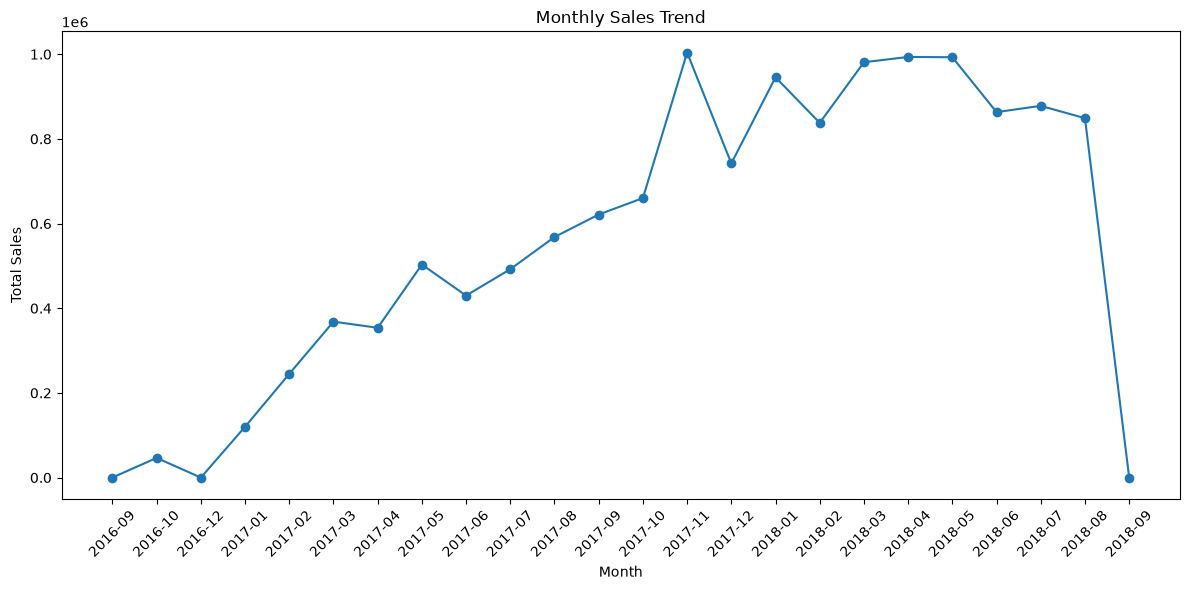

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["ORDER_MONTH"],
    monthly_sales["TOTAL_SALES"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# Calculate total sales by product category

category_sales = (
    order_items
    .merge(products, on="product_id", how="left")
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_sales.columns = ["PRODUCT_CATEGORY", "TOTAL_SALES"]

category_sales

NameError: name 'order_items' is not defined

In [16]:
category_sales = pd.read_sql(
    "SELECT * FROM VW_TOP_CATEGORIES ORDER BY TOTAL_REVENUE DESC FETCH FIRST 10 ROWS ONLY",
    con=connection
)
category_sales

C:\Users\START\AppData\Local\Temp\ipykernel_14776\2030375714.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_sales = pd.read_sql(


,PRODUCT_CATEGORY_NAME_ENGLISH,ITEMS_SOLD,TOTAL_REVENUE
0,health_beauty,9670,1258681.34
1,watches_gifts,5991,1205005.68
2,bed_bath_table,11115,1036988.68
3,sports_leisure,8641,988048.97
4,computers_accessories,7827,911954.32
5,furniture_decor,8334,729762.49
6,cool_stuff,3796,635290.85
7,housewares,6964,632248.66
8,auto,4235,592720.11
9,garden_tools,4347,485256.46


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
import oracledb

un = "PROJECT_USER"
pw = "1234"
dsn = "localhost:1521/FREEPDB1"

connection = oracledb.connect(user=un, password=pw, dsn=dsn)
print("✅ Connected to Oracle successfully!")


✅ Connected to Oracle successfully!


In [21]:
monthly_sales = pd.read_sql("SELECT * FROM VW_MONTHLY_SALES ORDER BY ORDER_MONTH", con=connection)
monthly_sales

C:\Users\START\AppData\Local\Temp\ipykernel_14776\1209014874.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_sales = pd.read_sql("SELECT * FROM VW_MONTHLY_SALES ORDER BY ORDER_MONTH", con=connection)


,ORDER_MONTH,TOTAL_ORDERS,TOTAL_SALES
0,2016-09,2,207.86
1,2016-10,296,46514.99
2,2016-12,1,10.90
3,2017-01,787,120098.27
4,2017-02,1718,244959.35
5,2017-03,2617,368341.32
6,2017-04,2377,353842.98
7,2017-05,3640,503159.19
8,2017-06,3205,429916.61
9,2017-07,3946,492287.30


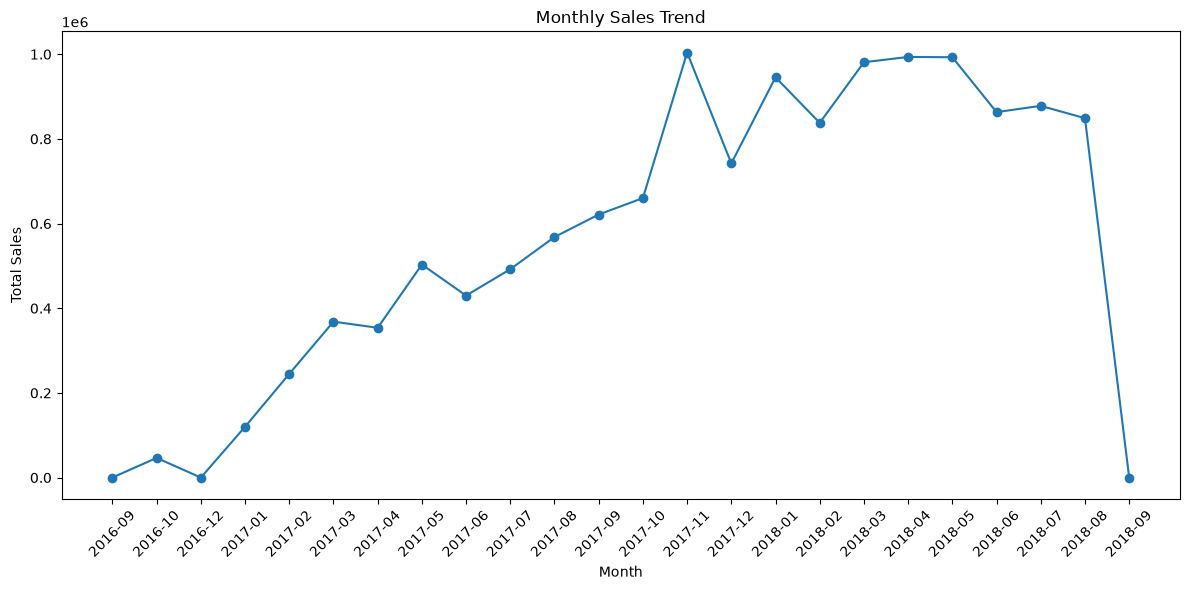

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["ORDER_MONTH"], monthly_sales["TOTAL_SALES"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [25]:
category_sales = pd.read_sql(
    "SELECT * FROM VW_TOP_CATEGORIES ORDER BY TOTAL_REVENUE DESC FETCH FIRST 10 ROWS ONLY",
    con=connection
)
category_sales

C:\Users\START\AppData\Local\Temp\ipykernel_14776\2030375714.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_sales = pd.read_sql(


,PRODUCT_CATEGORY_NAME_ENGLISH,ITEMS_SOLD,TOTAL_REVENUE
0,health_beauty,9670,1258681.34
1,watches_gifts,5991,1205005.68
2,bed_bath_table,11115,1036988.68
3,sports_leisure,8641,988048.97
4,computers_accessories,7827,911954.32
5,furniture_decor,8334,729762.49
6,cool_stuff,3796,635290.85
7,housewares,6964,632248.66
8,auto,4235,592720.11
9,garden_tools,4347,485256.46


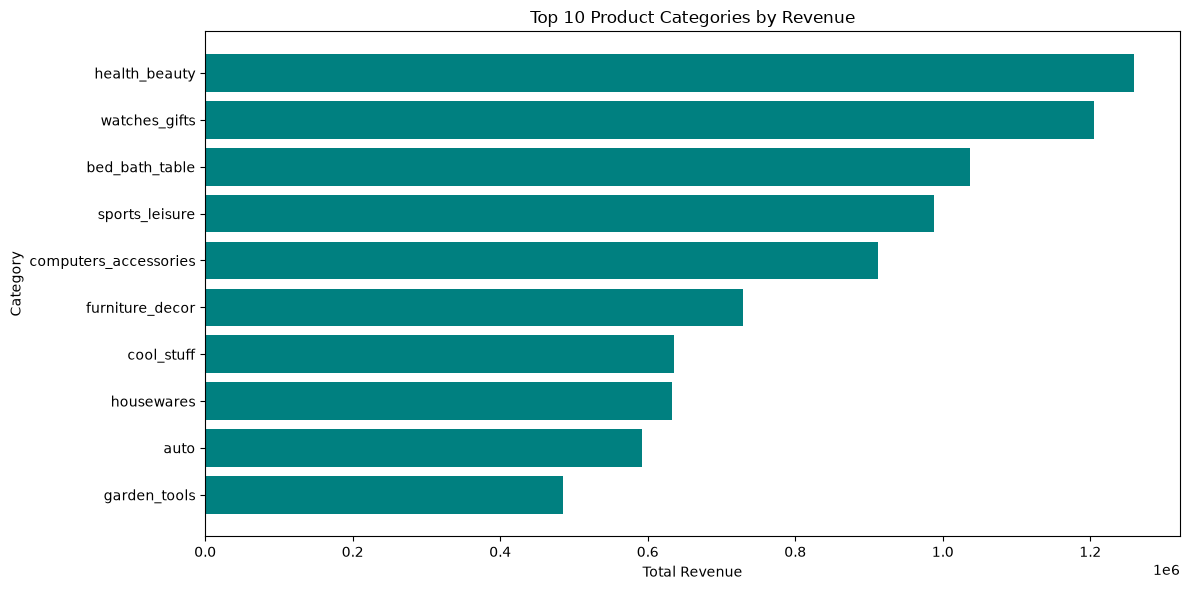

In [27]:
plt.figure(figsize=(12, 6))
plt.barh(category_sales["PRODUCT_CATEGORY_NAME_ENGLISH"], category_sales["TOTAL_REVENUE"], color="teal")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

In [29]:
best_sellers = pd.read_sql(
    "SELECT * FROM VW_BEST_SELLERS ORDER BY TOTAL_REVENUE DESC FETCH FIRST 10 ROWS ONLY",
    con=connection
)
best_sellers

C:\Users\START\AppData\Local\Temp\ipykernel_14776\4145402919.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  best_sellers = pd.read_sql(


,SELLER_ID,SELLER_CITY,SELLER_STATE,ITEMS_SOLD,TOTAL_REVENUE
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1156,229472.63
1,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,410,222776.05
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1987,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,586,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,1364,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,340,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1551,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1171,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,1428,138968.55
9,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,1499,135171.70


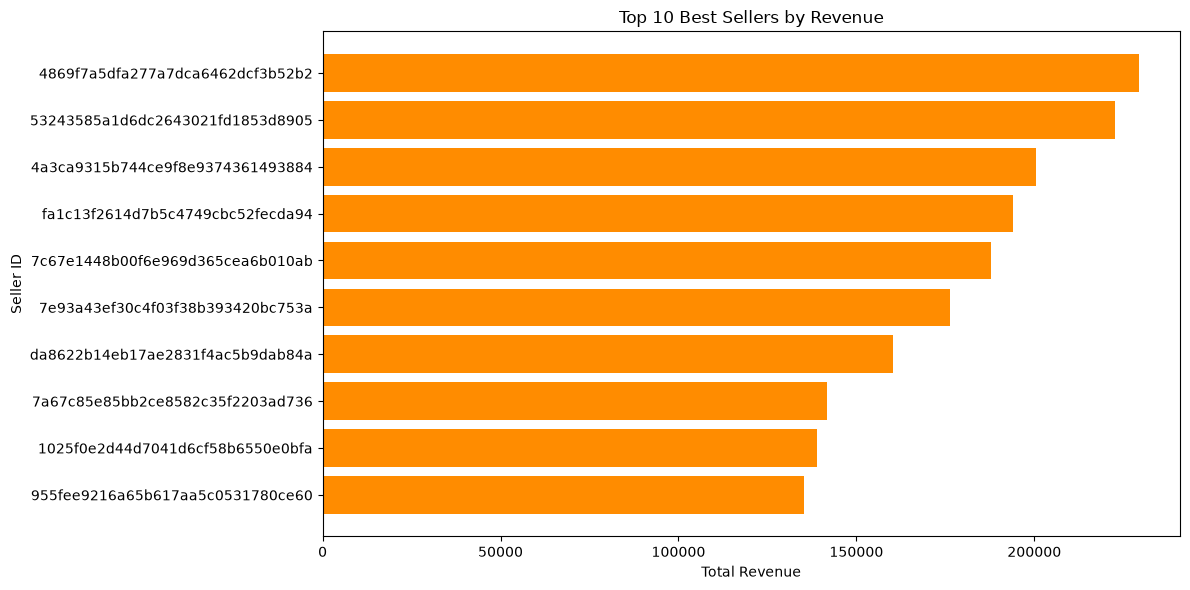

In [30]:
plt.figure(figsize=(12, 6))
plt.barh(best_sellers["SELLER_ID"], best_sellers["TOTAL_REVENUE"], color="darkorange")
plt.title("Top 10 Best Sellers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Seller ID")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
delivery_time = pd.read_sql("SELECT * FROM VW_DELIVERY_TIME", con=connection)
delivery_time["DELIVERY_DAYS"].describe()

C:\Users\START\AppData\Local\Temp\ipykernel_14776\2642554101.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  delivery_time = pd.read_sql("SELECT * FROM VW_DELIVERY_TIME", con=connection)


count    96476.000000
mean        12.497336
std          9.555460
min          0.000000
25%          7.000000
50%         10.000000
75%         16.000000
max        210.000000
Name: DELIVERY_DAYS, dtype: float64

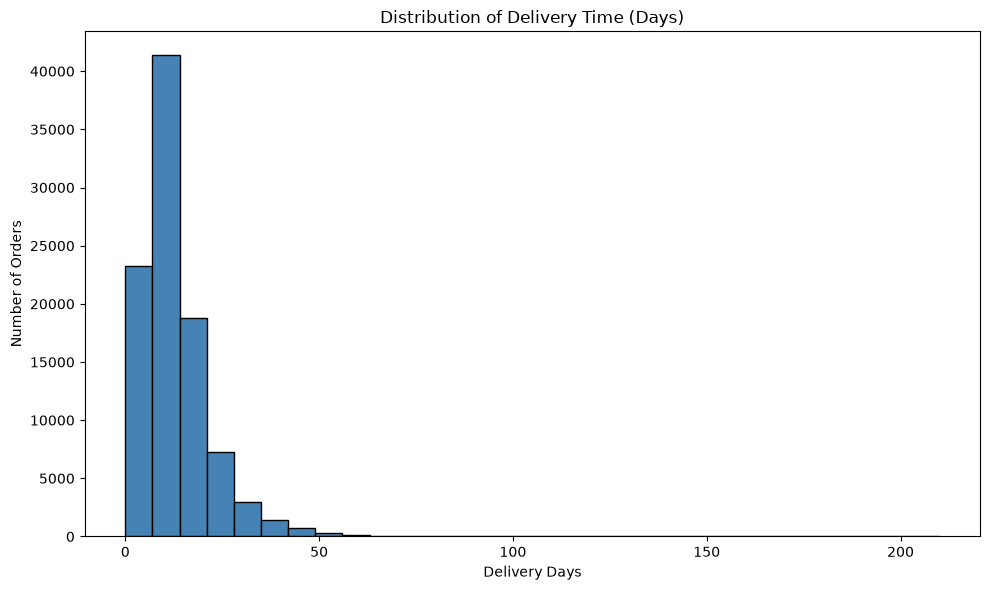

In [32]:
plt.figure(figsize=(10, 6))
plt.hist(delivery_time["DELIVERY_DAYS"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Delivery Time (Days)")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [33]:
delay_review = pd.read_sql(
    "SELECT DELIVERY_STATUS, AVG(REVIEW_SCORE) AS AVG_REVIEW_SCORE, COUNT(*) AS TOTAL_ORDERS "
    "FROM VW_DELAY_VS_REVIEW GROUP BY DELIVERY_STATUS",
    con=connection
)
delay_review

C:\Users\START\AppData\Local\Temp\ipykernel_14776\3514075624.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  delay_review = pd.read_sql(


,DELIVERY_STATUS,AVG_REVIEW_SCORE,TOTAL_ORDERS
0,On Time / Early,4.313957,73972
1,Delayed,2.279288,5224


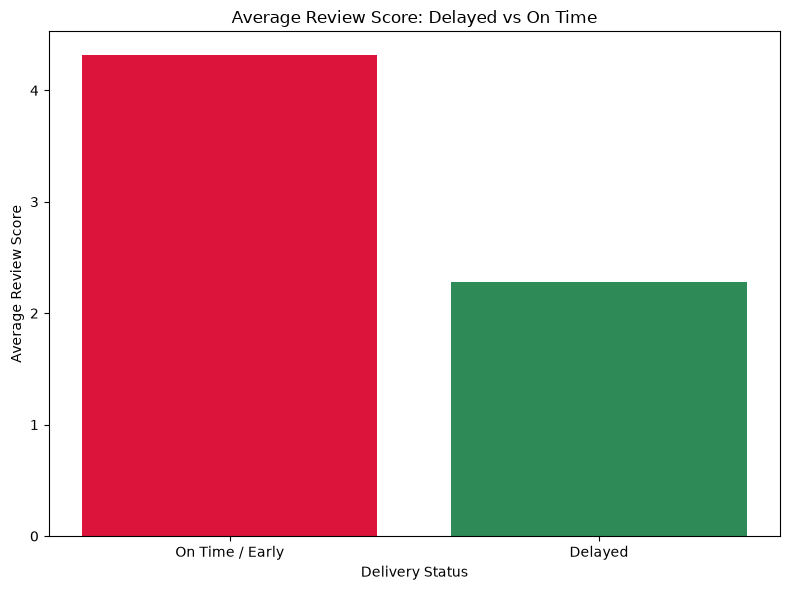

In [34]:
plt.figure(figsize=(8, 6))
plt.bar(delay_review["DELIVERY_STATUS"], delay_review["AVG_REVIEW_SCORE"], color=["crimson", "seagreen"])
plt.title("Average Review Score: Delayed vs On Time")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.show()

In [35]:
sales_by_state = pd.read_sql(
    "SELECT * FROM VW_SALES_BY_STATE ORDER BY TOTAL_REVENUE DESC FETCH FIRST 10 ROWS ONLY",
    con=connection
)
sales_by_state

C:\Users\START\AppData\Local\Temp\ipykernel_14776\1565819488.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_by_state = pd.read_sql(


,CUSTOMER_STATE,TOTAL_ORDERS,TOTAL_REVENUE
0,SP,41375,5202955.05
1,RJ,12762,1824092.67
2,MG,11544,1585308.03
3,RS,5432,750304.02
4,PR,4998,683083.76
5,SC,3612,520553.34
6,BA,3358,511349.99
7,DF,2125,302603.94
8,GO,2007,294591.95
9,ES,2025,275037.31


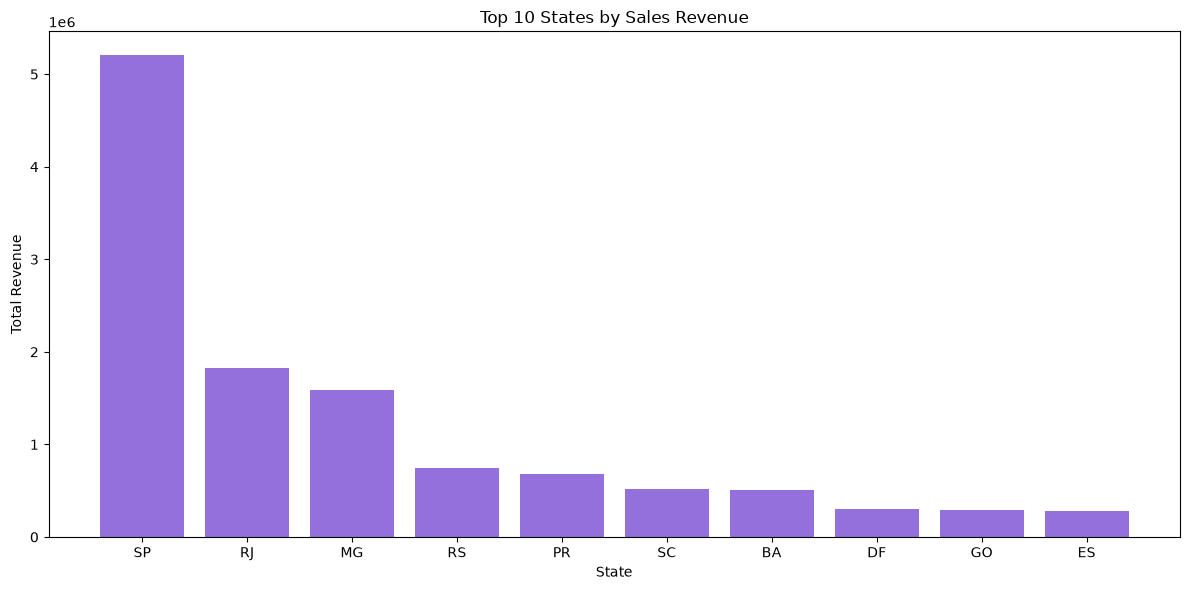

In [36]:
plt.figure(figsize=(12, 6))
plt.bar(sales_by_state["CUSTOMER_STATE"], sales_by_state["TOTAL_REVENUE"], color="mediumpurple")
plt.title("Top 10 States by Sales Revenue")
plt.xlabel("State")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

In [37]:
order_value = pd.read_sql("SELECT * FROM VW_ORDER_VALUE", con=connection)
avg_order_value = round(order_value["ORDER_TOTAL"].mean(), 2)
print(f"Average Order Value: {avg_order_value}")

C:\Users\START\AppData\Local\Temp\ipykernel_14776\770780090.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_value = pd.read_sql("SELECT * FROM VW_ORDER_VALUE", con=connection)


Average Order Value: 160.58


In [38]:
active_customers = pd.read_sql("SELECT COUNT(*) AS TOTAL_ACTIVE_CUSTOMERS FROM VW_ACTIVE_CUSTOMERS", con=connection)
active_customers

C:\Users\START\AppData\Local\Temp\ipykernel_14776\277505458.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  active_customers = pd.read_sql("SELECT COUNT(*) AS TOTAL_ACTIVE_CUSTOMERS FROM VW_ACTIVE_CUSTOMERS", con=connection)


,TOTAL_ACTIVE_CUSTOMERS
0,96478


In [39]:
payment_methods = pd.read_sql(
    "SELECT * FROM VW_PAYMENT_METHODS ORDER BY TOTAL_TRANSACTIONS DESC",
    con=connection
)
payment_methods

C:\Users\START\AppData\Local\Temp\ipykernel_14776\1054715422.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  payment_methods = pd.read_sql(


,PAYMENT_TYPE,TOTAL_TRANSACTIONS,TOTAL_VALUE,AVG_PAYMENT_VALUE
0,credit_card,76795,12542084.19,163.32
1,boleto,19784,2869361.27,145.03
2,voucher,5775,379436.87,65.70
3,debit_card,1529,217989.79,142.57
4,not_defined,3,0.00,0.00


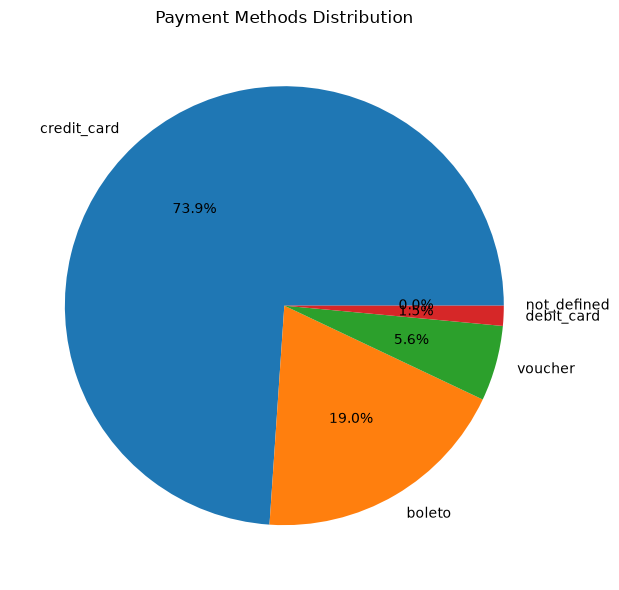

In [41]:
plt.figure(figsize=(8, 6))
plt.pie(payment_methods["TOTAL_TRANSACTIONS"], labels=payment_methods["PAYMENT_TYPE"], autopct="%1.1f%%")
plt.title("Payment Methods Distribution")
plt.tight_layout()
plt.show()plt.figure(figsize=(8, 6))
plt.pie(payment_methods["TOTAL_TRANSACTIONS"], labels=payment_methods["PAYMENT_TYPE"], autopct="%1.1f%%")
plt.title("Payment Methods Distribution")
plt.tight_layout()
plt.show()

In [ ]:
import oracledb

un = "PROJECT_USER"
pw = "1234"
dsn = "localhost:1521/FREEPDB1"

connection = oracledb.connect(user=un, password=pw, dsn=dsn)

print("✅ Connected to Oracle successfully!")

In [ ]:
connection.close()
print("🔒 Oracle connection closed.")

In [ ]:
import oracledb

un = "PROJECT_USER"
pw = "1234"
dsn = "localhost:1521/FREEPDB1"

connection = oracledb.connect(user=un, password=pw, dsn=dsn)

print("✅ Connected to Oracle successfully!")